# Compare notebook 05 populations

This report compares a named experiment with its recorded baseline. Start with the [experiment index](../docs/pilot_experiments.md). **Run All is read-only: it does not train, load models, use the GPU, or rerun simulations.** Use the project `.venv` kernel. Rerun it to refresh results while training continues, then save the notebook to retain its tables and embedded plots.

Choose `EXPERIMENT` below from `configs/pilot_experiments.json`, or override `EXPERIMENT_JOB` to inspect another prepared experiment. Its recorded plan supplies the baseline and training directories. Experiments run separately; this report never starts or resumes them.

The tables and plots use the same recorded metrics as notebook 05: checkpoint selection, test competence, behaviour, skill fractions, common validation reward components, learning curves, clean-win intervals and behaviour scatter. Results appear only when a pilot finishes training and testing; partial learning curves are labelled.

The original test has already informed this experiment, so it is now a **development comparison**. The separate **fresh confirmation** section becomes available after both populations have been evaluated on the predeclared new cases. Neither report changes checkpoints.


In [1]:
import json
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

REPO_ROOT = next(
    path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "bvr_behavior_prediction").is_dir()
)
# Choose a name from the registry. BVR_COMPARISON_JOB also accepts an unregistered job.
registry = json.loads((REPO_ROOT / "configs/pilot_experiments.json").read_text(encoding="utf8"))
EXPERIMENT = "lower_learning_rate"
EXPERIMENT_JOB = Path(os.getenv(
    "BVR_COMPARISON_JOB", str(REPO_ROOT / registry["experiments"][EXPERIMENT]["job"])
)).resolve()


def read_json(path):
    # A running process may be updating a manifest at the instant it is read.
    for attempt in range(3):
        try:
            return json.loads(path.read_text(encoding="utf8"))
        except json.JSONDecodeError:
            if attempt == 2:
                raise
            time.sleep(0.1)


def read_metrics(path):
    if not path.exists():
        return pd.DataFrame()
    lines = path.read_text(encoding="utf8").splitlines()
    rows = []
    for index, line in enumerate(lines):
        try:
            rows.append(json.loads(line))
        except json.JSONDecodeError:
            if index != len(lines) - 1:
                raise  # Only an incomplete final append is expected during training.
    return pd.DataFrame(rows)


plan = read_json(EXPERIMENT_JOB / "experiment.json")
EXPERIMENT_LABEL = plan.get("experiment_label", "Lower learning rate")
RUNS = {
    "Baseline": Path(plan["baseline"]),
    EXPERIMENT_LABEL: Path(plan["training_output"]),
}
status = read_json(EXPERIMENT_JOB / "status.json")
print(f"Experiment status: {status['status']}")
if "error" in status:
    print(status["error"])
print(plan.get("change_description", f"Learning rate: {plan['baseline_learning_rate']} -> {plan['learning_rate']}"))
print(f"Experiment: {EXPERIMENT_JOB}")
print("This report is a snapshot. Run All again to refresh it.")


Experiment status: completed
Learning rate: 0.0003 -> 3e-05
Experiment: C:\Users\jttur\VSCodeProjects\Trajectory_Classification\artifacts\rl_pilot_experiments\20261008T130810_285510Z_lr3e-05
This report is a snapshot. Run All again to refresh it.


## Progress and saved reward preferences

The same pilot ID refers to the same sampled reward coefficients in both runs. These are **coefficients**, not cumulative reward contributions. Training returns are comparable between the two versions of a given pilot; they are not a common score across pilots with different preferences.


In [2]:
batches = {
    name: read_json(directory / "pilots.json")
    if (directory / "pilots.json").exists() else {"pilots": []}
    for name, directory in RUNS.items()
}
metrics_by_run = {}
progress_rows, reward_rows, completed_rows = [], [], []
for name, batch in batches.items():
    metrics_by_run[name] = {}
    for pilot in batch["pilots"]:
        pilot_id = pilot["pilot_id"]
        directory = RUNS[name] / pilot.get("output_dir", pilot_id)
        metrics = read_metrics(directory / "training_metrics.jsonl")
        metrics_by_run[name][pilot_id] = metrics
        progress_rows.append({
            "run": name, "pilot_id": pilot_id, "status": pilot["status"],
            "epochs_finished": int(metrics["epoch"].max()) if not metrics.empty else 0,
            "epochs_planned": plan["epochs_per_pilot"],
        })
        reward_rows.append({
            "run": name, "pilot_id": pilot_id, "seed": pilot["seed"],
            **pilot["reward"]["parameters"]["weights"],
        })
        if pilot["status"] == "completed":
            completed_rows.append({"run": name, **pilot})

progress = pd.DataFrame(progress_rows)
display(progress)
display(pd.DataFrame(reward_rows).set_index(["run", "pilot_id"]))
print("Completed pilots:", {
    name: sum(p["status"] == "completed" for p in batch["pilots"])
    for name, batch in batches.items()
})


,run,pilot_id,status,epochs_finished,epochs_planned
0,Baseline,pilot_001,completed,150,150
1,Baseline,pilot_002,completed,150,150
2,Baseline,pilot_003,completed,150,150
3,Baseline,pilot_004,completed,150,150
4,Baseline,pilot_005,completed,150,150
5,Baseline,pilot_006,completed,150,150
6,Baseline,pilot_007,completed,150,150
7,Baseline,pilot_008,completed,150,150
8,Baseline,pilot_009,completed,150,150
9,Baseline,pilot_010,completed,150,150


seed     crashed   shot_down  ground_clearance  \
run                 pilot_id                                                    
Baseline            pilot_001     7 -333.906593 -384.168234              0.02   
                    pilot_002     7 -430.782955 -382.442109              0.02   
                    pilot_003     7 -366.812282 -440.427412              0.02   
                    pilot_004     7 -333.242475 -420.804194              0.02   
                    pilot_005     7 -401.126196 -394.431044              0.02   
                    pilot_006     7 -384.427212 -325.098271              0.02   
                    pilot_007     7 -347.625674 -429.037127              0.02   
                    pilot_008     7 -381.162634 -364.688821              0.02   
                    pilot_009     7 -354.792252 -366.963090              0.02   
                    pilot_010     7 -321.989539 -414.909077              0.02   
Lower learning rate pilot_001     7 -333.906593 -384.168234              0.02   
                    pilot_002     7 -430.782955 -382.442109              0.02   
                    pilot_003     7 -366.812282 -440.427412              0.02   
                    pilot_004     7 -333.242475 -420.804194              0.02   
                    pilot_005     7 -401.126196 -394.431044              0.02   
                    pilot_006     7 -384.427212 -325.098271              0.02   
                    pilot_007     7 -347.625674 -429.037127              0.02   
                    pilot_008     7 -381.162634 -364.688821              0.02   
                    pilot_009     7 -354.792252 -366.963090              0.02   
                    pilot_010     7 -321.989539 -414.909077              0.02   

                               target_lock_acquired  fired_with_lock  \
run                 pilot_id                                           
Baseline            pilot_001              1.394736         0.188355   
                    pilot_002              1.853530         1.287730   
                    pilot_003              1.263329         1.516175   
                    pilot_004              0.087608         0.308579   
                    pilot_005              0.378943         0.259843   
                    pilot_006              0.624733         1.664520   
                    pilot_007              0.014725         1.573849   
                    pilot_008              0.229060         1.336806   
                    pilot_009              0.607900         0.061636   
                    pilot_010              0.562768         0.587188   
Lower learning rate pilot_001              1.394736         0.188355   
                    pilot_002              1.853530         1.287730   
                    pilot_003              1.263329         1.516175   
                    pilot_004              0.087608         0.308579   
                    pilot_005              0.378943         0.259843   
                    pilot_006              0.624733         1.664520   
                    pilot_007              0.014725         1.573849   
                    pilot_008              0.229060         1.336806   
                    pilot_009              0.607900         0.061636   
                    pilot_010              0.562768         0.587188   

                               incoming_missile_avoided  opponent_destroyed  \
run                 pilot_id                                                  
Baseline            pilot_001                 14.634335               250.0   
                    pilot_002                 12.341424               250.0   
                    pilot_003                  5.317890               250.0   
                    pilot_004                 10.245734               250.0   
                    pilot_005                  7.135574               250.0   
                    pilot_006                 12.071465               250.0   
                    pilot_007  

Completed pilots: {'Baseline': 10, 'Lower learning rate': 10}


## Checkpoint selection and original test competence

These reproduce notebook 05's first two result tables, with a run column. **Selection return** uses each pilot's own reward. **Benchmark return** uses the common reward on validation scenarios. The second table reports the separate original test cases, now used for development comparison.

A clean win means a confirmed missile elimination while surviving. The shared outcome score is +100 for a clean win, 0 for survival without a confirmed elimination, -50 for mutual destruction and -100 for own loss with the opponent alive. Confidence intervals describe scenario uncertainty, not variation between repeated training seeds. Missing results mean pending, not zero.


In [3]:
summary = pd.DataFrame(completed_rows)
test_summary = pd.DataFrame([
    {"run": pilot["run"], "pilot_id": pilot["pilot_id"], **pilot["test"]}
    for pilot in completed_rows if "test" in pilot
])
COMPETENCE_COLUMNS = [
    "run", "pilot_id", "scenarios", "clean_win_rate", "clean_win_ci95",
    "mutual_destruction_rate", "survival_rate", "elimination_rate", "outcome_score",
]
BEHAVIOUR_COLUMNS = [
    "run", "pilot_id", "mean_missiles_launched", "mean_missiles_avoided",
    "mean_threatened_seconds", "mean_duration_seconds",
]


def show_competence(frame):
    if frame.empty:
        print("No completed evaluations yet.")
    else:
        display(frame[COMPETENCE_COLUMNS].sort_values(
            ["run", "clean_win_rate", "outcome_score"], ascending=[True, False, False]
        ))


if not summary.empty:
    display(summary[[
        "run", "pilot_id", "selection_return", "benchmark_return", "checkpoint"
    ]])
show_competence(test_summary)


,run,pilot_id,selection_return,benchmark_return,checkpoint
0,Baseline,pilot_001,22.895715,145.5272,pilot_001/best_model.pt
1,Baseline,pilot_002,63.094107,207.7428,pilot_002/best_model.pt
2,Baseline,pilot_003,-77.511940,144.3612,pilot_003/best_model.pt
3,Baseline,pilot_004,-18.205263,163.8684,pilot_004/best_model.pt
4,Baseline,pilot_005,31.466191,198.1444,pilot_005/best_model.pt
5,Baseline,pilot_006,65.482665,195.5908,pilot_006/best_model.pt
6,Baseline,pilot_007,26.328528,199.2636,pilot_007/best_model.pt
7,Baseline,pilot_008,58.721444,209.1888,pilot_008/best_model.pt
8,Baseline,pilot_009,34.487819,168.6804,pilot_009/best_model.pt
9,Baseline,pilot_010,29.888653,199.1396,pilot_010/best_model.pt


,run,pilot_id,scenarios,clean_win_rate,clean_win_ci95,mutual_destruction_rate,survival_rate,elimination_rate,outcome_score
9,Baseline,pilot_010,100,0.36,"[0.2727122040140433, 0.4576459754839126]",0.25,0.63,0.61,11.5
4,Baseline,pilot_005,100,0.32,"[0.23669147324999093, 0.41662618610452384]",0.36,0.55,0.68,5.0
1,Baseline,pilot_002,100,0.32,"[0.23669147324999093, 0.41662618610452384]",0.37,0.54,0.69,4.5
0,Baseline,pilot_001,100,0.29,"[0.2101483574912227, 0.3853889117557111]",0.11,0.71,0.40,5.5
5,Baseline,pilot_006,100,0.29,"[0.2101483574912227, 0.3853889117557111]",0.34,0.59,0.63,5.0
7,Baseline,pilot_008,100,0.29,"[0.2101483574912227, 0.3853889117557111]",0.40,0.51,0.69,0.0
3,Baseline,pilot_004,100,0.26,"[0.18404698464748132, 0.3537098944918718]",0.41,0.44,0.67,-9.5
8,Baseline,pilot_009,100,0.25,"[0.17545211362287672, 0.34304463548061603]",0.23,0.65,0.48,1.5
6,Baseline,pilot_007,100,0.24,"[0.16691325556948772, 0.33232336349814473]",0.31,0.62,0.55,1.5
2,Baseline,pilot_003,100,0.20,"[0.1333669333310325, 0.2888291655931589]",0.38,0.52,0.58,-9.0


## Original test behaviour and common validation components

Missile use, threat exposure and skill fractions describe observed behaviour; they are not measures of competence by themselves. The final table contains **mean cumulative points per flight under the common validation reward**, exactly as in notebook 05. Each row sums to that pilot's validation benchmark return. These values are not reward coefficients.


In [4]:
def show_behaviour(frame):
    if frame.empty:
        print("No completed behaviour evaluations yet.")
        return
    display(frame[BEHAVIOUR_COLUMNS])
    skills = pd.DataFrame([
        {"run": row["run"], "pilot_id": row["pilot_id"], **row["skill_decision_fractions"]}
        for _, row in frame.iterrows()
    ]).set_index(["run", "pilot_id"]).fillna(0.0)
    display(skills)


show_behaviour(test_summary)
if completed_rows:
    print("Common validation reward components: mean points per flight")
    display(pd.DataFrame([
        {"run": pilot["run"], "pilot_id": pilot["pilot_id"],
         **pilot["benchmark_component_means"]}
        for pilot in completed_rows
    ]).set_index(["run", "pilot_id"]))


,run,pilot_id,mean_missiles_launched,mean_missiles_avoided,mean_threatened_seconds,mean_duration_seconds
0,Baseline,pilot_001,0.84,3.62,75.058,88.628
1,Baseline,pilot_002,1.17,2.64,66.069,76.368
2,Baseline,pilot_003,0.85,2.74,66.437,78.921
3,Baseline,pilot_004,1.01,2.04,60.980,73.235
4,Baseline,pilot_005,1.44,2.53,67.216,76.248
5,Baseline,pilot_006,1.73,3.14,66.410,79.521
6,Baseline,pilot_007,1.52,3.38,68.373,82.499
7,Baseline,pilot_008,1.33,2.66,65.869,75.302
8,Baseline,pilot_009,0.67,3.22,69.402,84.573
9,Baseline,pilot_010,1.04,3.08,70.058,80.988


abort_support  beam_missile_left  \
run                 pilot_id                                      
Baseline            pilot_001       0.000563           0.042886   
                    pilot_002       0.000000           0.012511   
                    pilot_003       0.017803           0.000000   
                    pilot_004       0.231992           0.140120   
                    pilot_005       0.000000           0.067894   
                    pilot_006       0.000000           0.012403   
                    pilot_007       0.044828           0.006887   
                    pilot_008       0.318873           0.064542   
                    pilot_009       0.000000           0.035028   
                    pilot_010       0.000000           0.040949   
Lower learning rate pilot_001       0.000934           0.090697   
                    pilot_002       0.000508           0.021988   
                    pilot_003       0.015214           0.041174   
                    pilot_004       0.001860           0.011744   
                    pilot_005       0.013401           0.040565   
                    pilot_006       0.000000           0.014977   
                    pilot_007       0.003875           0.003632   
                    pilot_008       0.000000           0.004575   
                    pilot_009       0.062840           0.047372   
                    pilot_010       0.013628           0.027632   

                               beam_missile_right  climb_to_altitude  \
run                 pilot_id                                           
Baseline            pilot_001            0.027578           0.003489   
                    pilot_002            0.046136           0.221686   
                    pilot_003            0.000000           0.055808   
                    pilot_004            0.001087           0.001767   
                    pilot_005            0.018671           0.000131   
                    pilot_006            0.000000           0.513405   
                    pilot_007            0.000967           0.021508   
                    pilot_008            0.034122           0.060706   
                    pilot_009            0.000000           0.298266   
                    pilot_010            0.018323           0.229464   
Lower learning rate pilot_001            0.010039           0.222949   
                    pilot_002            0.009278           0.266650   
                    pilot_003            0.011591           0.101546   
                    pilot_004            0.013023           0.000116   
                    pilot_005            0.005191           0.041531   
                    pilot_006            0.026719           0.026480   
                    pilot_007            0.004601           0.095290   
                    pilot_008            0.004810           0.159667   
                    pilot_009            0.004230           0.015831   
                    pilot_010            0.012378           0.003751   

                               crank_target_left  decelerate_to_speed  \
run                 pilot_id                                            
Baseline            pilot_001           0.008555             0.000338   
                    pilot_002           0.050437             0.000000   
                    pilot_003           0.000000             0.049495   
                    pilot_004           0.000000             0.000000   
                    pilot_005           0.009140             0.009662   
                    pilot_006           0.000000             0.000000   
                    pilot_007           0.000846             0.000000   
                    pilot_008           0.000000             0.000000   
                    pilot_009           0.002123             0.000826   
                    pilot_010           0.068126             0.059518   
Lower learning rate pilot_001           0.096300             0.010739   
                    pi

Common validation reward components: mean points per flight


crashed  fired_with_lock  fired_without_lock  \
run                 pilot_id                                                  
Baseline            pilot_001      0.0             8.80                 0.0   
                    pilot_002      0.0            12.00                 0.0   
                    pilot_003      0.0             8.80                 0.0   
                    pilot_004      0.0             9.28                 0.0   
                    pilot_005      0.0            13.60                 0.0   
                    pilot_006      0.0            16.32                 0.0   
                    pilot_007      0.0            17.12                 0.0   
                    pilot_008      0.0            11.04                 0.0   
                    pilot_009      0.0             6.88                 0.0   
                    pilot_010      0.0            11.36                 0.0   
Lower learning rate pilot_001      0.0             5.76                 0.0   
                    pilot_002      0.0            16.64                 0.0   
                    pilot_003      0.0            11.36                 0.0   
                    pilot_004      0.0            16.80                 0.0   
                    pilot_005      0.0             8.96                 0.0   
                    pilot_006      0.0            17.60                 0.0   
                    pilot_007      0.0            12.16                 0.0   
                    pilot_008      0.0            13.12                 0.0   
                    pilot_009      0.0            10.72                 0.0   
                    pilot_010      0.0            10.56                 0.0   

                               ground_clearance  missile_avoided  \
run                 pilot_id                                       
Baseline            pilot_001            1.4872             56.4   
                    pilot_002            1.3428             47.6   
                    pilot_003            1.3212             38.4   
                    pilot_004            1.3084             40.4   
                    pilot_005            1.3444             46.4   
                    pilot_006            1.3108             45.2   
                    pilot_007            1.3836             58.0   
                    pilot_008            1.3488             50.0   
                    pilot_009            1.5204             58.4   
                    pilot_010            1.3796             49.6   
Lower learning rate pilot_001            1.4784             59.6   
                    pilot_002            1.3680             53.6   
                    pilot_003            1.4116             53.2   
                    pilot_004            1.4524             56.4   
                    pilot_005            1.4232             51.2   
                    pilot_006            1.4804             61.2   
                    pilot_007            1.4296             58.0   
                    pilot_008            1.4356             54.8   
                    pilot_009            1.4224             51.2   
                    pilot_010            1.4220             55.6   

                               opponent_destroyed  shot_down  target_locked  
run                 pilot_id                                                 
Baseline            pilot_001               140.0      -63.0           1.84  
                    pilot_002               220.0      -75.0           1.80  
                    pilot_003               190.0      -96.0           1.84  
                    pilot_004               195.0      -84.0           1.88  
                    pilot_005               210.0      -75.0           1.80  
                    pilot_006               215.0      -84.0           1.76  
                    pilot_007               190.0      -69.0           1.76  
                    pilot_008               220.0      -75.0           1.80  
               

## Learning curves, including pilots still training

Each row compares matching reward preferences. Colours distinguish runs; line styles distinguish training, validation and best validation return. The right panel shows the actor and critic losses in their learning units. Partial curves are labelled with their last completed epoch. Lower loss alone does not establish better combat performance.

For selected-skill experiments, policy loss, entropy and KL use a different action probability definition. Their absolute values are not directly comparable with the unmasked baseline. Value loss retains its definition, but each policy collects different flights. Judge improvement by the matched outcome evaluations.


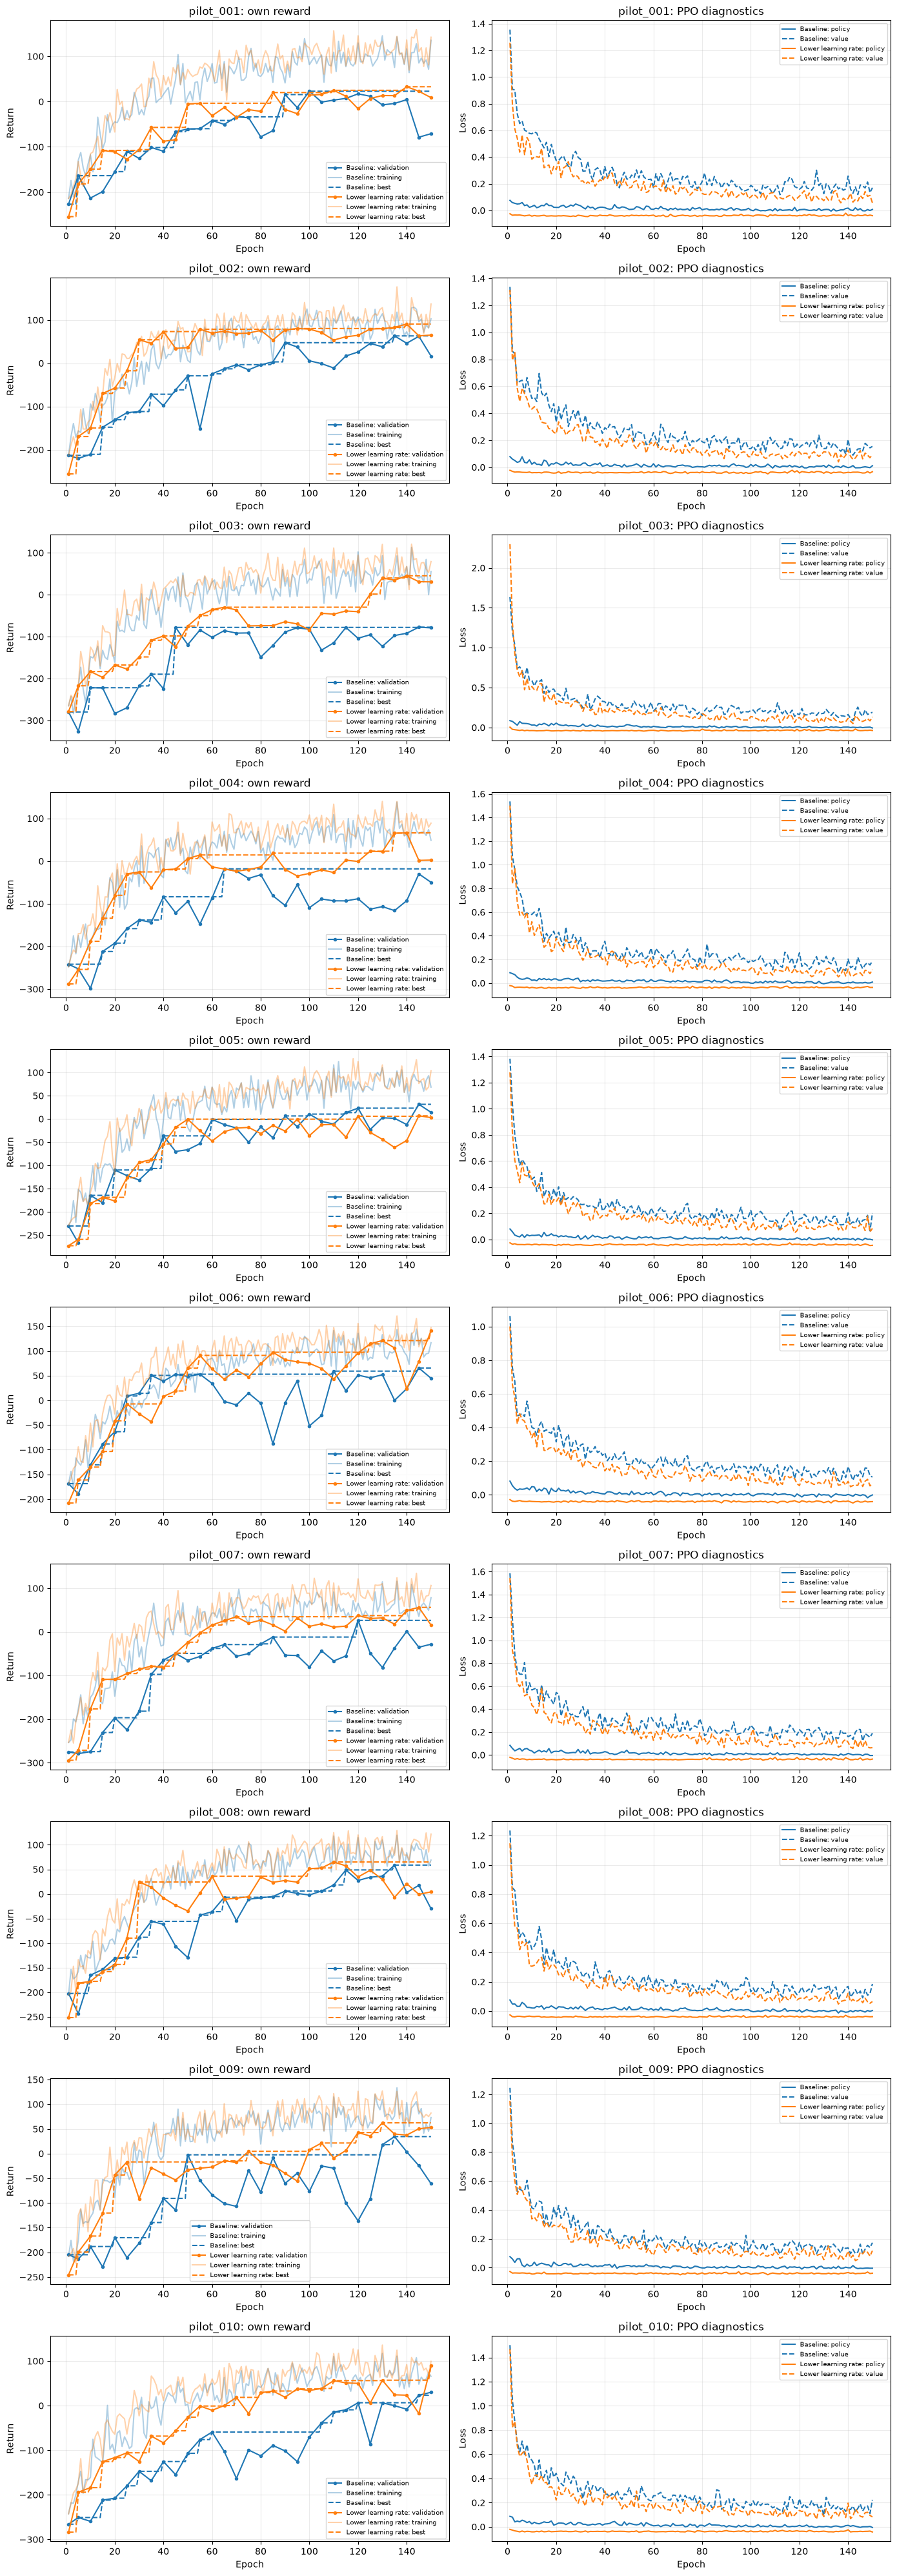

In [5]:
COLOURS = {"Baseline": "tab:blue", EXPERIMENT_LABEL: "tab:orange"}
pilot_ids = sorted({
    pilot_id for metrics in metrics_by_run.values()
    for pilot_id, frame in metrics.items() if not frame.empty
})
if pilot_ids:
    figure, axes = plt.subplots(len(pilot_ids), 2, figsize=(14, 4 * len(pilot_ids)), squeeze=False)
    for row, pilot_id in enumerate(pilot_ids):
        for name, records in metrics_by_run.items():
            metrics = records.get(pilot_id, pd.DataFrame())
            if metrics.empty:
                continue
            pilot_status = next(p["status"] for p in batches[name]["pilots"] if p["pilot_id"] == pilot_id)
            label = name
            if pilot_status != "completed":
                label += f" ({pilot_status}, epoch {int(metrics['epoch'].max())})"
            evaluated = metrics[metrics["evaluation_performed"] == 1]
            colour = COLOURS[name]
            axes[row, 0].plot(evaluated["epoch"], evaluated["mean_return"],
                              marker=".", color=colour, label=f"{label}: validation")
            axes[row, 0].plot(metrics["epoch"], metrics["training_mean_return"],
                              alpha=0.35, color=colour, label=f"{label}: training")
            axes[row, 0].plot(metrics["epoch"], metrics["best_return"],
                              linestyle="--", color=colour, label=f"{label}: best")
            if {"policy_loss", "value_loss"}.issubset(metrics.columns):
                axes[row, 1].plot(metrics["epoch"], metrics["policy_loss"],
                                  color=colour, label=f"{label}: policy")
                axes[row, 1].plot(metrics["epoch"], metrics["value_loss"],
                                  linestyle="--", color=colour, label=f"{label}: value")
            else:
                axes[row, 1].plot(metrics["epoch"], metrics["loss"], color=colour, label=label)
        axes[row, 0].set(title=f"{pilot_id}: own reward", xlabel="Epoch", ylabel="Return")
        axes[row, 1].set(title=f"{pilot_id}: PPO diagnostics", xlabel="Epoch", ylabel="Loss")
        for axis in axes[row]:
            axis.grid(alpha=0.25)
            axis.legend(fontsize=7)
    figure.tight_layout()
    plt.show()
else:
    print("No recorded epochs yet.")


## Original test plots

These show the same clean-win intervals and behaviour scatter as notebook 05, with both runs on the same axes. A missing bar is a pending result, not a zero clean-win rate. The Wilson intervals are per pilot and run; use the paired comparison below to assess changes on matching scenarios.


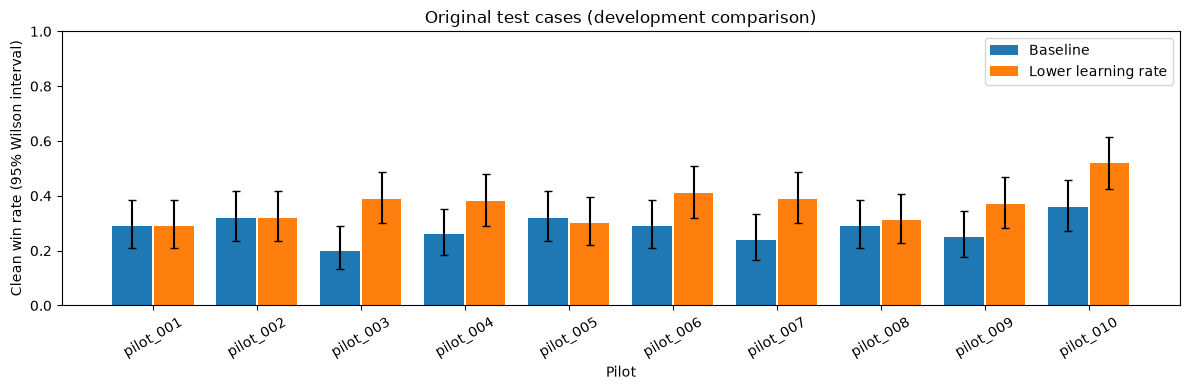

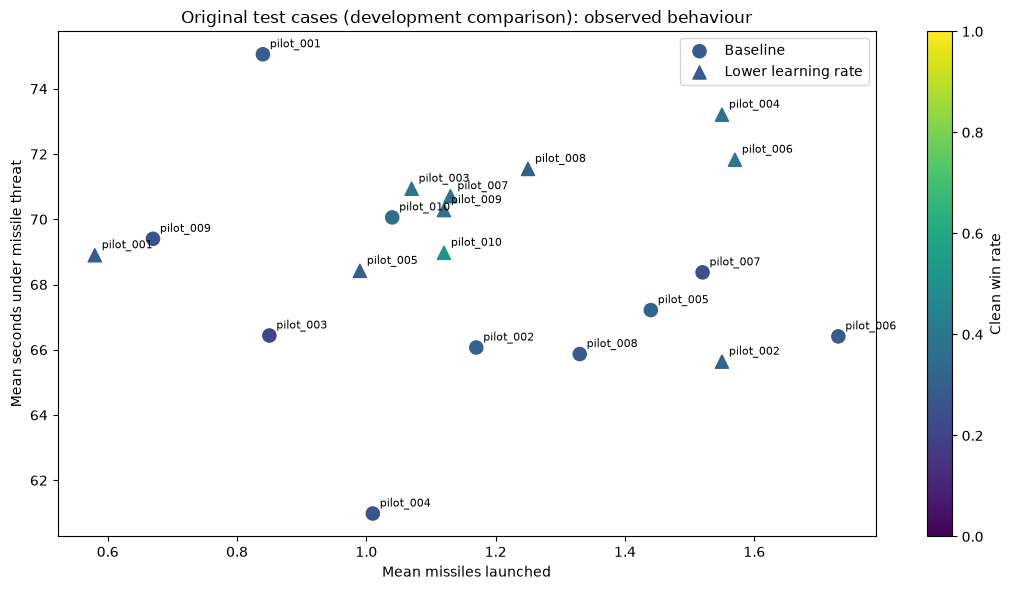

In [6]:
def plot_evaluation(frame, title):
    if frame.empty:
        print(f"{title}: no completed evaluations yet.")
        return
    pilot_ids = sorted(frame["pilot_id"].unique())
    positions = np.arange(len(pilot_ids))
    figure, axis = plt.subplots(figsize=(12, 4))
    for offset, (name, colour) in zip((-0.2, 0.2), COLOURS.items()):
        data = frame[frame["run"] == name]
        if data.empty:
            continue
        x = np.asarray([pilot_ids.index(pilot_id) for pilot_id in data["pilot_id"]])
        rate = data["clean_win_rate"].to_numpy()
        bounds = np.asarray(data["clean_win_ci95"].tolist())
        errors = np.maximum(0, np.vstack((rate - bounds[:, 0], bounds[:, 1] - rate)))
        axis.bar(x + offset, rate, width=0.38, yerr=errors, capsize=3, color=colour, label=name)
    axis.set(xticks=positions, xticklabels=pilot_ids, ylim=(0, 1), xlabel="Pilot",
             ylabel="Clean win rate (95% Wilson interval)", title=title)
    axis.tick_params(axis="x", labelrotation=30)
    axis.legend()
    figure.tight_layout()
    plt.show()

    figure, axis = plt.subplots(figsize=(11, 6))
    points = None
    for name, marker in zip(COLOURS, ("o", "^")):
        data = frame[frame["run"] == name].dropna(
            subset=["mean_missiles_launched", "mean_threatened_seconds"]
        )
        if data.empty:
            continue
        points = axis.scatter(
            data["mean_missiles_launched"], data["mean_threatened_seconds"],
            c=data["clean_win_rate"], vmin=0, vmax=1, s=90, cmap="viridis",
            marker=marker, label=name,
        )
        for _, pilot in data.iterrows():
            axis.annotate(pilot["pilot_id"],
                          (pilot["mean_missiles_launched"], pilot["mean_threatened_seconds"]),
                          xytext=(5, 5), textcoords="offset points", fontsize=8)
    axis.set(title=f"{title}: observed behaviour",
             xlabel="Mean missiles launched", ylabel="Mean seconds under missile threat")
    if points is not None:
        figure.colorbar(points, ax=axis, label="Clean win rate")
        axis.legend()
    figure.tight_layout()
    plt.show()


plot_evaluation(test_summary, "Original test cases (development comparison)")


## Fresh confirmation: the same evaluation tables and plots

After training, the runner evaluates **both populations** on the predeclared fresh scenarios. This section reads those results as they arrive. It uses the same outcome definitions, behaviour measurements and plots as above. Until both populations finish, these are partial results; the final population comparison appears in the next section.


Predeclared suite: {'seed': 420000, 'scenarios': 100}


,run,pilot_id,scenarios,clean_win_rate,clean_win_ci95,mutual_destruction_rate,survival_rate,elimination_rate,outcome_score
9,Baseline,pilot_010,100,0.55,"[0.45244602997442135, 0.6438546202048803]",0.19,0.74,0.74,38.5
4,Baseline,pilot_005,100,0.51,"[0.4134801193402717, 0.6057800106955886]",0.25,0.68,0.76,31.5
1,Baseline,pilot_002,100,0.51,"[0.4134801193402717, 0.6057800106955886]",0.25,0.67,0.76,30.5
0,Baseline,pilot_001,100,0.50,"[0.4038315303659956, 0.5961684696340044]",0.13,0.77,0.63,33.5
7,Baseline,pilot_008,100,0.47,"[0.3751081795934127, 0.5671114302990063]",0.29,0.63,0.76,24.5
3,Baseline,pilot_004,100,0.43,"[0.33733298524110106, 0.5278461045078768]",0.35,0.57,0.78,17.5
5,Baseline,pilot_006,100,0.41,"[0.3186731302113651, 0.5079856994658921]",0.31,0.65,0.72,21.5
8,Baseline,pilot_009,100,0.41,"[0.3186731302113651, 0.5079856994658921]",0.15,0.72,0.56,20.5
6,Baseline,pilot_007,100,0.34,"[0.25461520797348164, 0.43722271145275377]",0.34,0.61,0.68,12.0
2,Baseline,pilot_003,100,0.32,"[0.23669147324999093, 0.41662618610452384]",0.38,0.56,0.70,7.0


,run,pilot_id,mean_missiles_launched,mean_missiles_avoided,mean_threatened_seconds,mean_duration_seconds
0,Baseline,pilot_001,1.24,3.25,71.835,85.236
1,Baseline,pilot_002,1.57,2.74,66.133,77.308
2,Baseline,pilot_003,0.96,2.51,64.678,77.791
3,Baseline,pilot_004,1.01,2.26,62.211,74.865
4,Baseline,pilot_005,1.53,2.56,66.709,76.815
5,Baseline,pilot_006,2.29,3.02,64.001,77.790
6,Baseline,pilot_007,2.05,2.88,64.577,78.295
7,Baseline,pilot_008,1.52,2.80,65.864,76.787
8,Baseline,pilot_009,0.83,3.23,70.712,85.258
9,Baseline,pilot_010,1.13,3.00,68.282,79.949


abort_support  beam_missile_left  \
run                 pilot_id                                      
Baseline            pilot_001       0.000467           0.084940   
                    pilot_002       0.000000           0.018554   
                    pilot_003       0.012161           0.000000   
                    pilot_004       0.154194           0.184235   
                    pilot_005       0.000000           0.117998   
                    pilot_006       0.000000           0.011906   
                    pilot_007       0.024573           0.010441   
                    pilot_008       0.263260           0.084425   
                    pilot_009       0.000000           0.061594   
                    pilot_010       0.000000           0.091384   
Lower learning rate pilot_001       0.000000           0.098221   
                    pilot_002       0.000978           0.048533   
                    pilot_003       0.019392           0.063748   
                    pilot_004       0.002512           0.027515   
                    pilot_005       0.012689           0.081381   
                    pilot_006       0.000000           0.022675   
                    pilot_007       0.017398           0.004204   
                    pilot_008       0.000000           0.017297   
                    pilot_009       0.090452           0.070474   
                    pilot_010       0.013434           0.064210   

                               beam_missile_right  climb_to_altitude  \
run                 pilot_id                                           
Baseline            pilot_001            0.044281           0.005258   
                    pilot_002            0.039814           0.209638   
                    pilot_003            0.000384           0.050563   
                    pilot_004            0.000665           0.021933   
                    pilot_005            0.025026           0.000259   
                    pilot_006            0.001024           0.448854   
                    pilot_007            0.001273           0.024573   
                    pilot_008            0.034756           0.057580   
                    pilot_009            0.000000           0.283193   
                    pilot_010            0.007719           0.273904   
Lower learning rate pilot_001            0.009409           0.289730   
                    pilot_002            0.016015           0.201222   
                    pilot_003            0.019856           0.102531   
                    pilot_004            0.017810           0.000000   
                    pilot_005            0.006101           0.050878   
                    pilot_006            0.029379           0.039863   
                    pilot_007            0.007707           0.089211   
                    pilot_008            0.001909           0.112132   
                    pilot_009            0.007599           0.012747   
                    pilot_010            0.019719           0.003574   

                               crank_target_left  descend_to_altitude  \
run                 pilot_id                                            
Baseline            pilot_001           0.004673             0.005959   
                    pilot_002           0.040716             0.069965   
                    pilot_003           0.000000             0.000000   
                    pilot_004           0.000000             0.000000   
                    pilot_005           0.007261             0.000000   
                    pilot_006           0.000000             0.000000   
                    pilot_007           0.002292             0.287751   
                    pilot_008           0.000000             0.029698   
                    pilot_009           0.001169             0.000000   
                    pilot_010           0.047311             0.000000   
Lower learning rate pilot_001           0.088009             0.000229   
                    pi

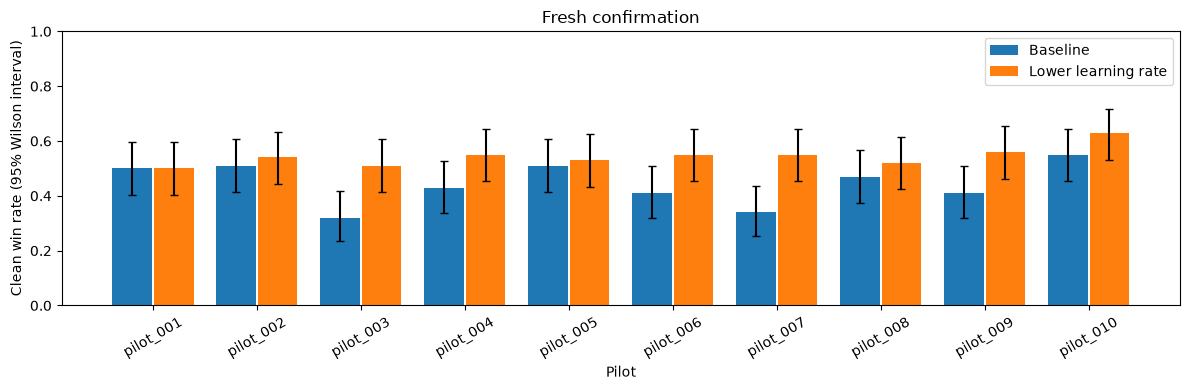

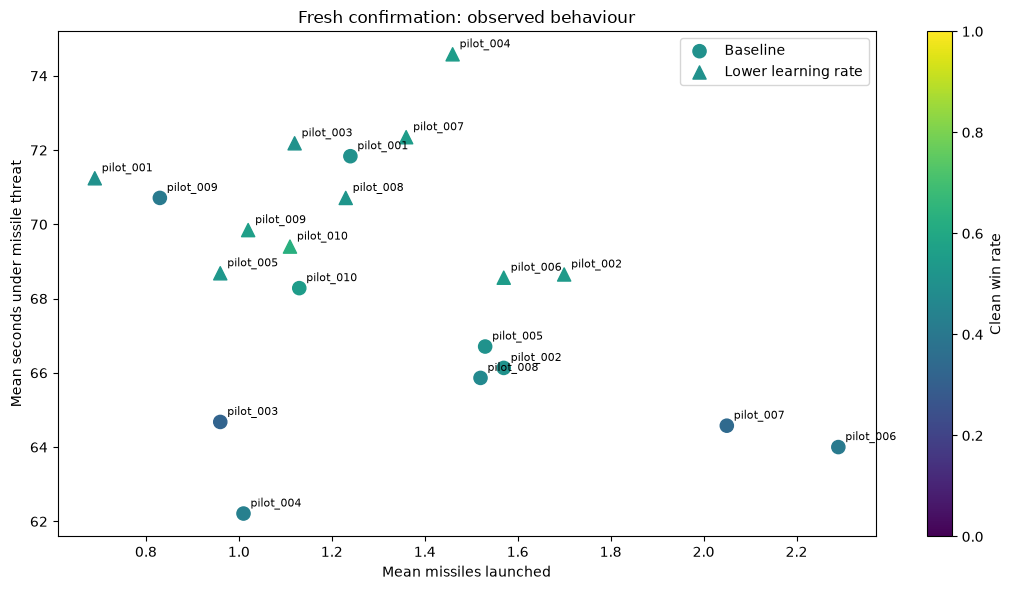

In [7]:
confirmation_rows = []
for population, name in (("baseline", "Baseline"), ("experiment", EXPERIMENT_LABEL)):
    for path in sorted((EXPERIMENT_JOB / "confirmation" / population).glob("*/evaluation.json")):
        evaluation = read_json(path)
        confirmation_rows.append({
            "run": name, "pilot_id": path.parent.name, **evaluation["summary"]
        })
confirmation_summary = pd.DataFrame(confirmation_rows)
print(f"Predeclared suite: {plan['confirmation']}")
show_competence(confirmation_summary)
show_behaviour(confirmation_summary)
plot_evaluation(confirmation_summary, "Fresh confirmation")


## Matched differences and overall result

The runner writes this comparison only after the relevant suite is complete for the whole population. The primary measure is the mean clean-win rate over all matching reward profiles, not the best pilot. Gained/lost wins count identical cases whose clean-win outcome changed.

The paired bootstrap resamples scenarios jointly across pilots; its interval measures scenario uncertainty. One training seed does not establish a robust improvement. Judge the fresh confirmation alongside survival and mutual destruction; do not select a checkpoint using it.


In [8]:
comparison_path = EXPERIMENT_JOB / "comparison.json"
if comparison_path.exists():
    comparison = read_json(comparison_path)
    aggregate_rows = []
    for suite, title in (
        ("existing_test", "Original test (development)"),
        ("fresh_confirmation", "Fresh confirmation"),
    ):
        if suite not in comparison:
            continue
        values = comparison[suite]
        display(Markdown(f"**{title}: paired changes**"))
        display(pd.DataFrame(values["pilots"]))
        aggregate_rows.append({
            "suite": title,
            "baseline_mean_clean_win_rate": values["baseline_mean_clean_win_rate"],
            "experiment_mean_clean_win_rate": values["experiment_mean_clean_win_rate"],
            "change_percentage_points": values["difference_percentage_points"],
            "paired_change_ci95_percentage_points":
                values["paired_scenario_bootstrap_ci95_percentage_points"],
        })
    display(pd.DataFrame(aggregate_rows))
    print(f"Report status: {comparison['status']}")
    print(f"Standalone report: {EXPERIMENT_JOB / 'comparison.html'}")
else:
    print("The full-population comparison will appear after all pilots finish training and testing.")
print("Save this notebook after refreshing to retain the displayed tables and embedded figures.")


**Original test (development): paired changes**

,pilot_id,scenarios,baseline_clean_win_rate,experiment_clean_win_rate,difference_percentage_points,gained_clean_wins,lost_clean_wins,baseline_survival_rate,experiment_survival_rate,baseline_mutual_destruction_rate,experiment_mutual_destruction_rate
0,pilot_001,100,0.29,0.29,0.0,6,6,0.71,0.68,0.11,0.12
1,pilot_002,100,0.32,0.32,0.0,3,3,0.54,0.58,0.37,0.37
2,pilot_003,100,0.20,0.39,19.0,21,2,0.52,0.65,0.38,0.28
3,pilot_004,100,0.26,0.38,12.0,24,12,0.44,0.72,0.41,0.23
4,pilot_005,100,0.32,0.30,-2.0,7,9,0.55,0.65,0.36,0.18
5,pilot_006,100,0.29,0.41,12.0,14,2,0.59,0.69,0.34,0.26
6,pilot_007,100,0.24,0.39,15.0,16,1,0.62,0.68,0.31,0.20
7,pilot_008,100,0.29,0.31,2.0,9,7,0.51,0.68,0.40,0.25
8,pilot_009,100,0.25,0.37,12.0,19,7,0.65,0.65,0.23,0.27
9,pilot_010,100,0.36,0.52,16.0,16,0,0.63,0.67,0.25,0.24


**Fresh confirmation: paired changes**

,pilot_id,scenarios,baseline_clean_win_rate,experiment_clean_win_rate,difference_percentage_points,gained_clean_wins,lost_clean_wins,baseline_survival_rate,experiment_survival_rate,baseline_mutual_destruction_rate,experiment_mutual_destruction_rate
0,pilot_001,100,0.50,0.50,0.0,4,4,0.77,0.78,0.13,0.10
1,pilot_002,100,0.51,0.54,3.0,6,3,0.67,0.74,0.25,0.22
2,pilot_003,100,0.32,0.51,19.0,24,5,0.56,0.72,0.38,0.20
3,pilot_004,100,0.43,0.55,12.0,20,8,0.57,0.80,0.35,0.16
4,pilot_005,100,0.51,0.53,2.0,7,5,0.68,0.74,0.25,0.14
5,pilot_006,100,0.41,0.55,14.0,16,2,0.65,0.77,0.31,0.20
6,pilot_007,100,0.34,0.55,21.0,21,0,0.61,0.78,0.34,0.17
7,pilot_008,100,0.47,0.52,5.0,8,3,0.63,0.77,0.29,0.17
8,pilot_009,100,0.41,0.56,15.0,18,3,0.72,0.75,0.15,0.17
9,pilot_010,100,0.55,0.63,8.0,9,1,0.74,0.76,0.19,0.18


,suite,baseline_mean_clean_win_rate,experiment_mean_clean_win_rate,change_percentage_points,paired_change_ci95_percentage_points
0,Original test (development),0.282,0.368,8.6,"[4.500000000000001, 12.9]"
1,Fresh confirmation,0.445,0.544,9.9,"[6.497499999999999, 13.402499999999987]"


Report status: completed
Standalone report: C:\Users\jttur\VSCodeProjects\Trajectory_Classification\artifacts\rl_pilot_experiments\20261008T130810_285510Z_lr3e-05\comparison.html
Save this notebook after refreshing to retain the displayed tables and embedded figures.
